In [22]:
# -- imports & paths
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

SUMMARY_DIR = Path("summary")
FIG_DIR = SUMMARY_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

In [23]:
# -- coalesce all CSVs
# filename format: {model_family}_{classification}_{classifier}_{prompt}.csv
records = []
for fpath in sorted(SUMMARY_DIR.glob("*.csv")):
    parts = fpath.stem.split("_")
    model_family   = parts[0]
    classification = parts[1]
    classifier     = parts[2]
    prompt         = "debate" if parts[3] == "dabate" else parts[3]

    df = pd.read_csv(fpath)
    df["rel_layer"]      = df["layer"] / (len(df) - 1)
    df["model_family"]   = model_family
    df["classification"] = classification
    df["classifier"]     = classifier
    df["prompt"]         = prompt
    if "stage2_auroc" not in df.columns:
        df["stage2_auroc"] = np.nan
    records.append(df)

master = pd.concat(records, ignore_index=True)

configs = (
    master[["model_family", "classification", "classifier", "prompt"]]
    .drop_duplicates()
    .sort_values(["model_family", "classification", "classifier", "prompt"])
    .reset_index(drop=True)
)
print(f"{len(master)} total rows  {len(configs)} configs")
configs

KeyError: 'layer'

In [ ]:
# -- plotting helpers
COMBOS  = [("3way", "lr"), ("3way", "mlp"), ("cascaded", "lr"), ("cascaded", "mlp")]
CLABELS = ["3-way LR",    "3-way MLP",    "Cascaded LR",      "Cascaded MLP"]
C1, C2  = "steelblue", "tomato"

CLASS_COLS   = ["f1_deception", "f1_honest_mistake", "f1_truth"]
CLASS_LABELS = ["Deception",    "Honest Mistake",    "Truth"]


def _draw_lines(ax, df, cond_col, val1, val2, label1, label2, ycol):
    d1 = df[df[cond_col] == val1].sort_values("rel_layer")
    d2 = df[df[cond_col] == val2].sort_values("rel_layer")
    l1, = ax.plot(d1["rel_layer"], d1[ycol], color=C1, lw=2,        label=label1)
    l2, = ax.plot(d2["rel_layer"], d2[ycol], color=C2, lw=2, ls="--", label=label2)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    return l1, l2


def plot_macro_f1(df, cond_col, val1, val2, label1, label2, title, save_path):
    """2x2 grid: one subplot per classifier combo, 2 lines per subplot."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, (cls, clf), clabel in zip(axes.flatten(), COMBOS, CLABELS):
        sub = df[(df["classification"] == cls) & (df["classifier"] == clf)]
        _draw_lines(ax, sub, cond_col, val1, val2, label1, label2, "f1_macro")
        ax.set_title(clabel, fontweight="bold")
        ax.set_xlabel("Relative layer depth")
        ax.set_ylabel("Macro F1")
        ax.legend(fontsize=9)
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {save_path}")


def plot_perclass_f1(df, cond_col, val1, val2, label1, label2, title, save_path):
    """3x4 grid: rows=class (deception/honest_mistake/truth), cols=classifier combo."""
    fig, axes = plt.subplots(3, 4, figsize=(20, 11), sharey=True)
    for row, (ccol, clname) in enumerate(zip(CLASS_COLS, CLASS_LABELS)):
        for col, ((cls, clf), clabel) in enumerate(zip(COMBOS, CLABELS)):
            ax = axes[row, col]
            sub = df[(df["classification"] == cls) & (df["classifier"] == clf)]
            _draw_lines(ax, sub, cond_col, val1, val2, label1, label2, ccol)
            if row == 0:
                ax.set_title(clabel, fontweight="bold")
            if col == 0:
                ax.set_ylabel(f"{clname} F1", fontsize=10)
            if row == 2:
                ax.set_xlabel("Relative layer depth")
            if row == 0 and col == 0:
                ax.legend(fontsize=9)
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {save_path}")

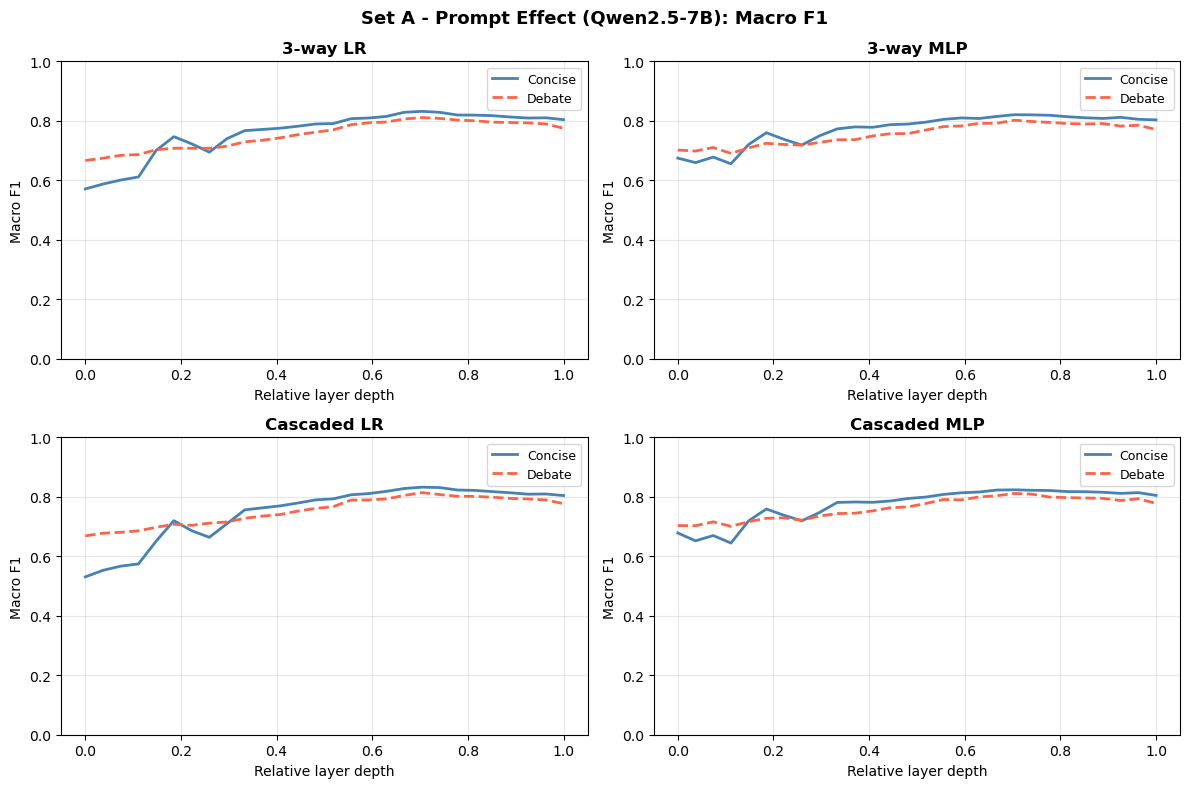

Saved to summary\figures\setA_macro_f1.png


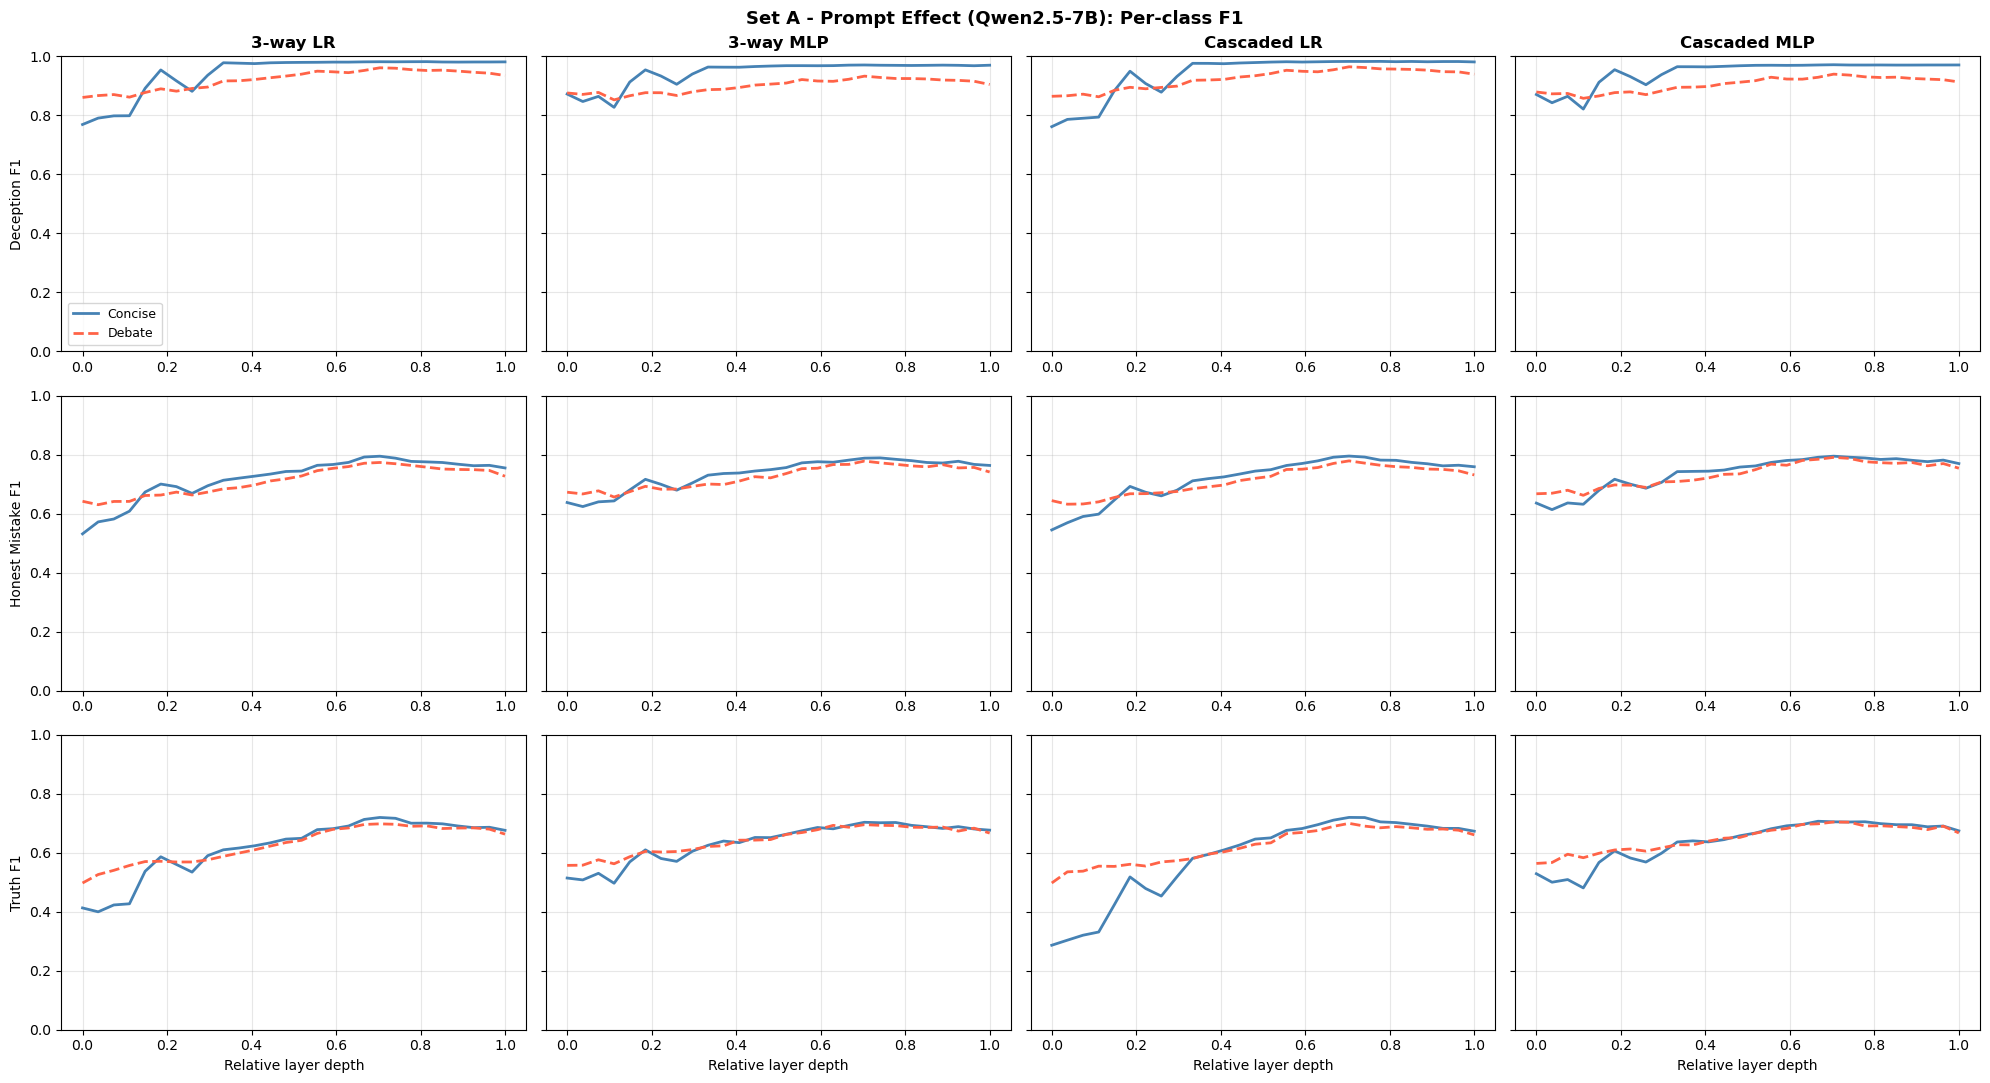

Saved to summary\figures\setA_perclass_f1.png


In [ ]:
# -- Set A: prompt effect (qwen2.5 concise vs debate)
df_A = master[master["model_family"] == "qwen2.5"]

plot_macro_f1(
    df_A, "prompt", "concise", "debate", "Concise", "Debate",
    "Set A - Prompt Effect (Qwen2.5-7B): Macro F1",
    FIG_DIR / "setA_macro_f1.png",
)
plot_perclass_f1(
    df_A, "prompt", "concise", "debate", "Concise", "Debate",
    "Set A - Prompt Effect (Qwen2.5-7B): Per-class F1",
    FIG_DIR / "setA_perclass_f1.png",
)

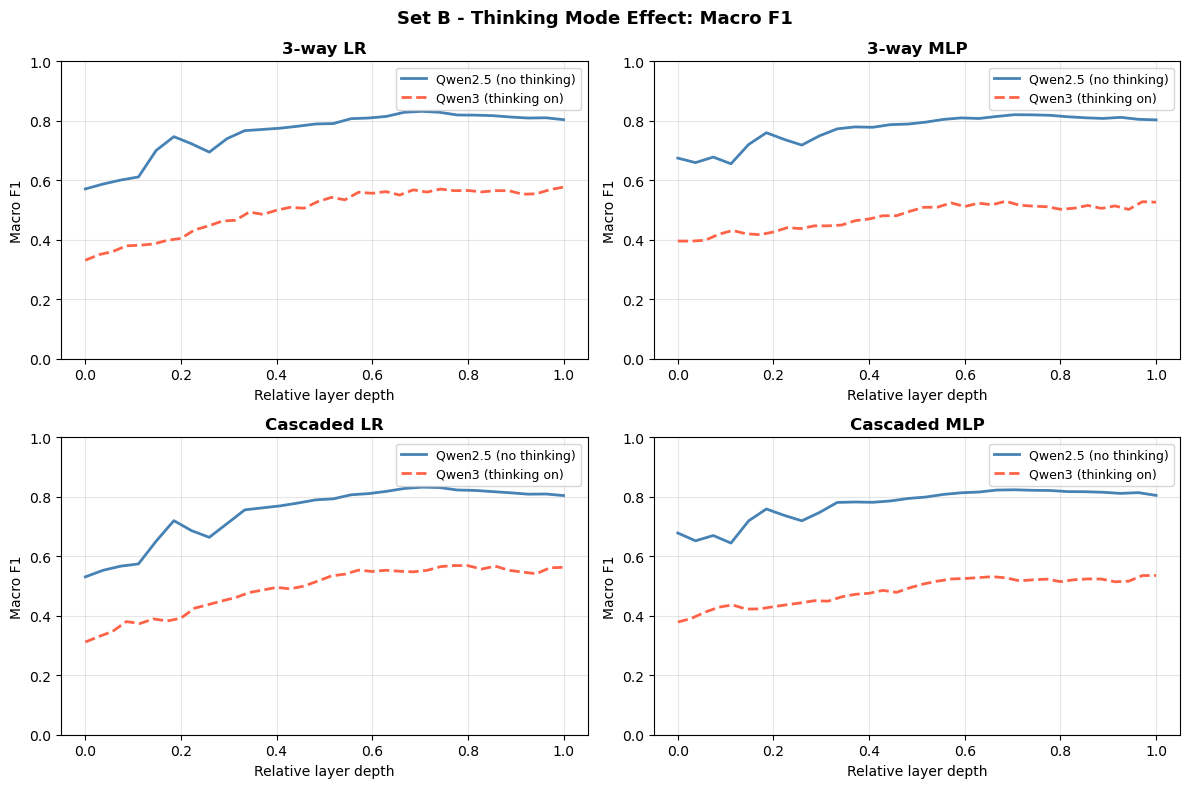

Saved to summary\figures\setB_macro_f1.png


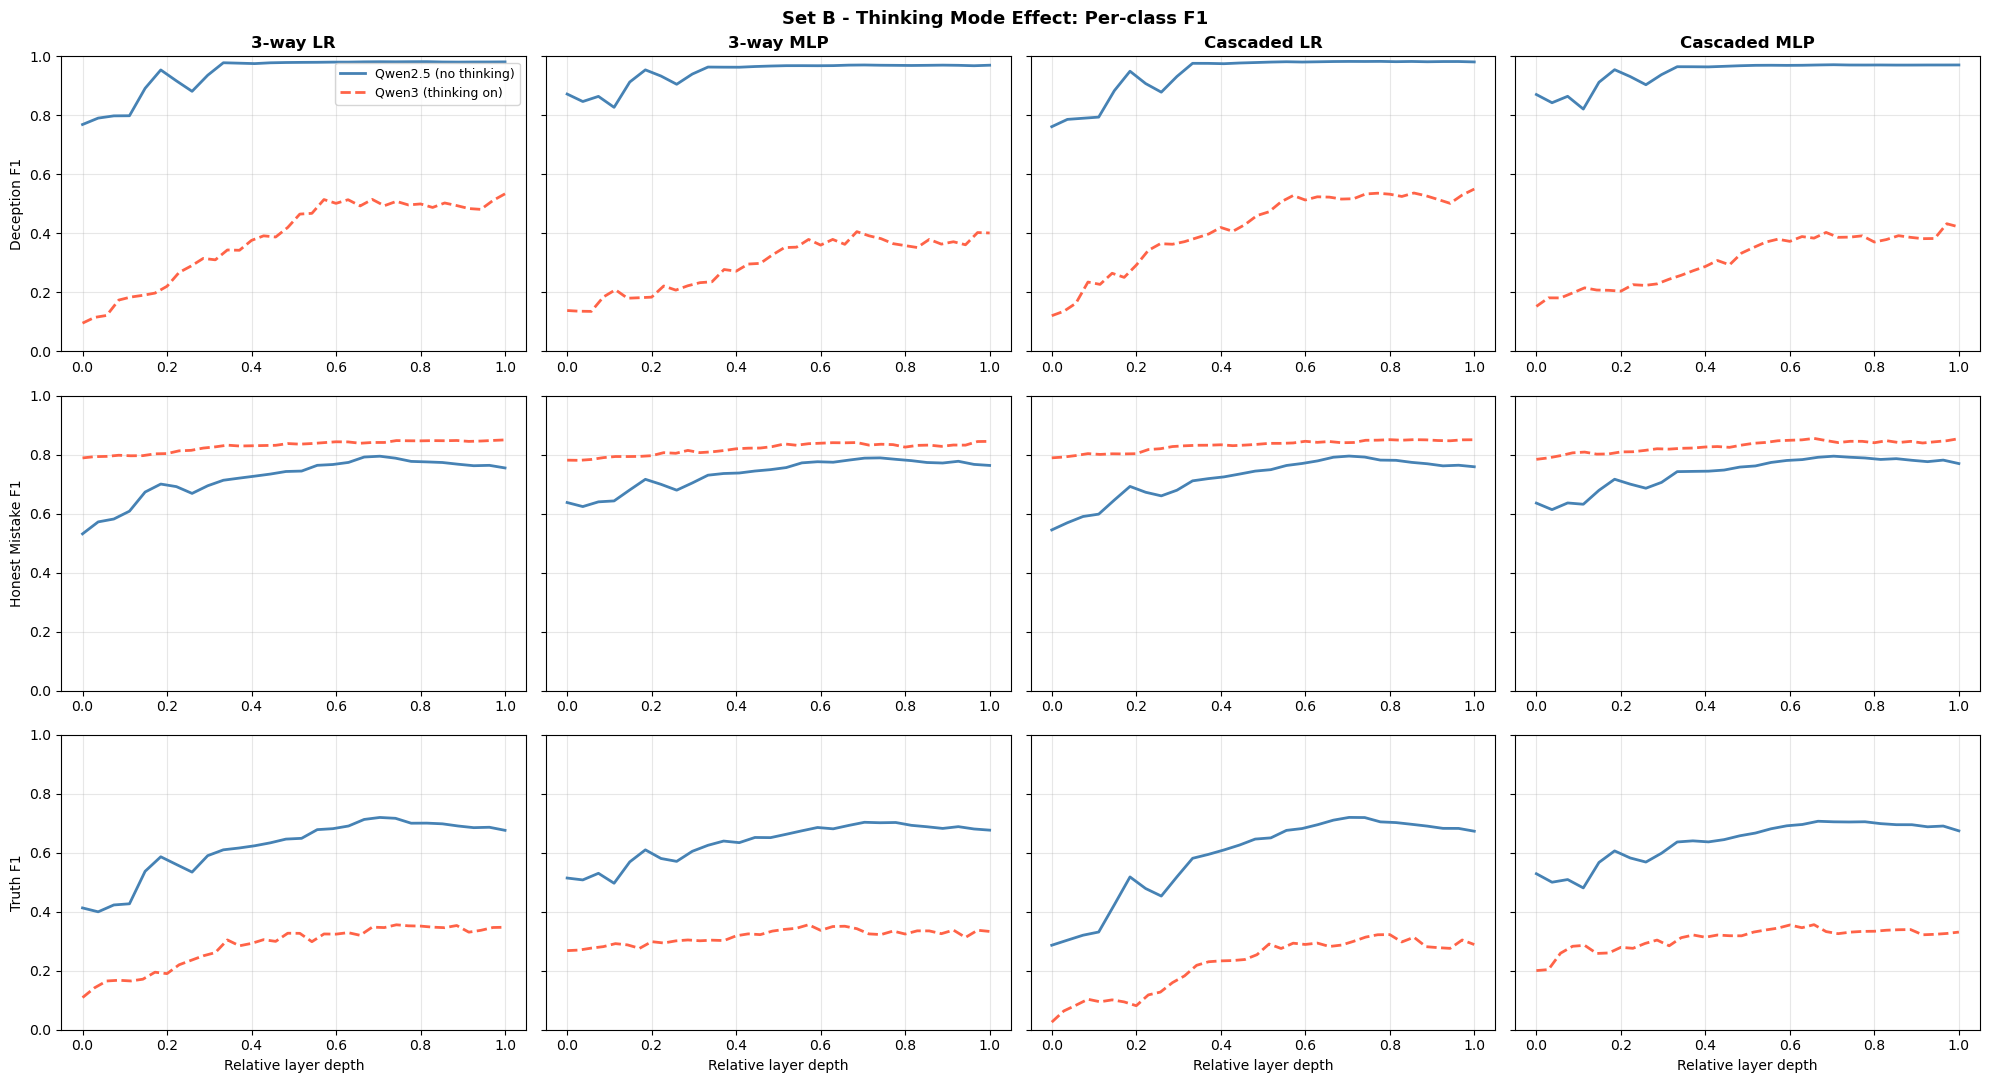

Saved to summary\figures\setB_perclass_f1.png


In [ ]:
# -- Set B: thinking mode (qwen2.5 concise vs qwen3 concise)
# qwen2.5 = no thinking; qwen3 = thinking on
# x-axis is relative layer depth so the different layer counts (28 vs 36) align
df_concise = master[master["prompt"] == "concise"]

plot_macro_f1(
    df_concise, "model_family", "qwen2.5", "qwen3",
    "Qwen2.5 (no thinking)", "Qwen3 (thinking on)",
    "Set B - Thinking Mode Effect: Macro F1",
    FIG_DIR / "setB_macro_f1.png",
)
plot_perclass_f1(
    df_concise, "model_family", "qwen2.5", "qwen3",
    "Qwen2.5 (no thinking)", "Qwen3 (thinking on)",
    "Set B - Thinking Mode Effect: Per-class F1",
    FIG_DIR / "setB_perclass_f1.png",
)

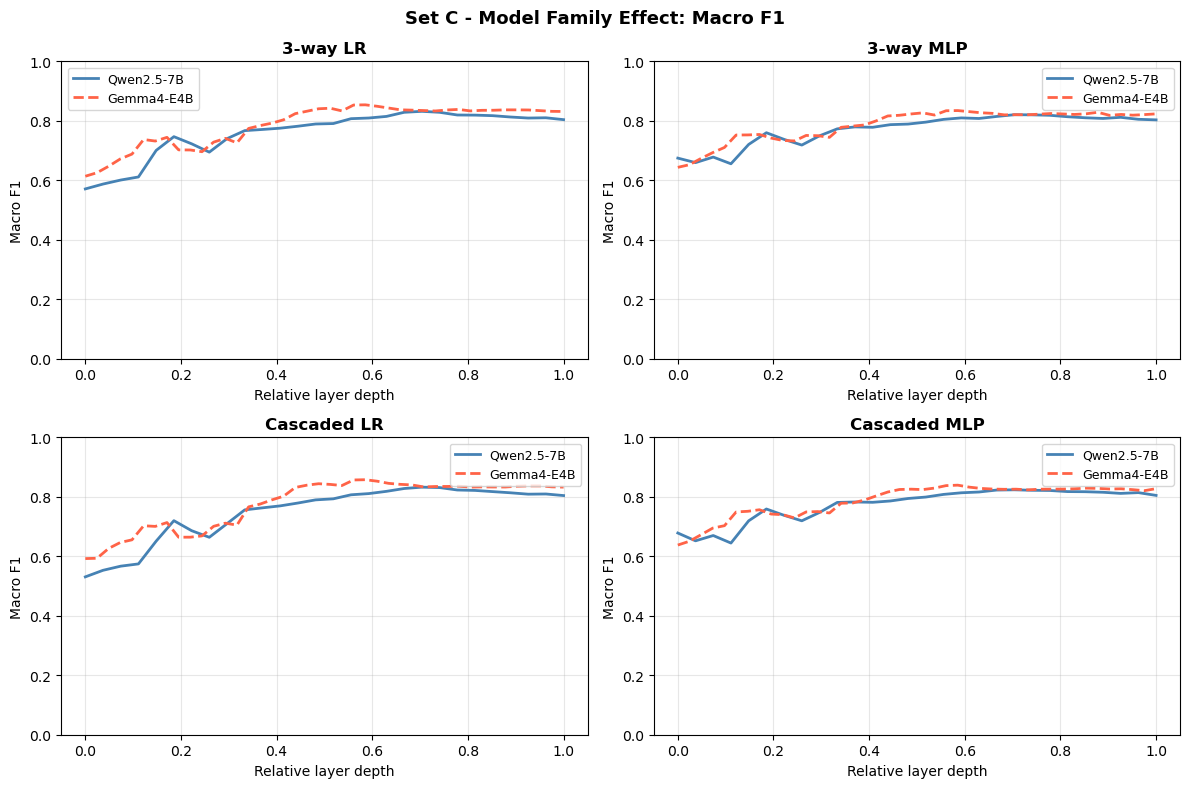

Saved to summary\figures\setC_macro_f1.png


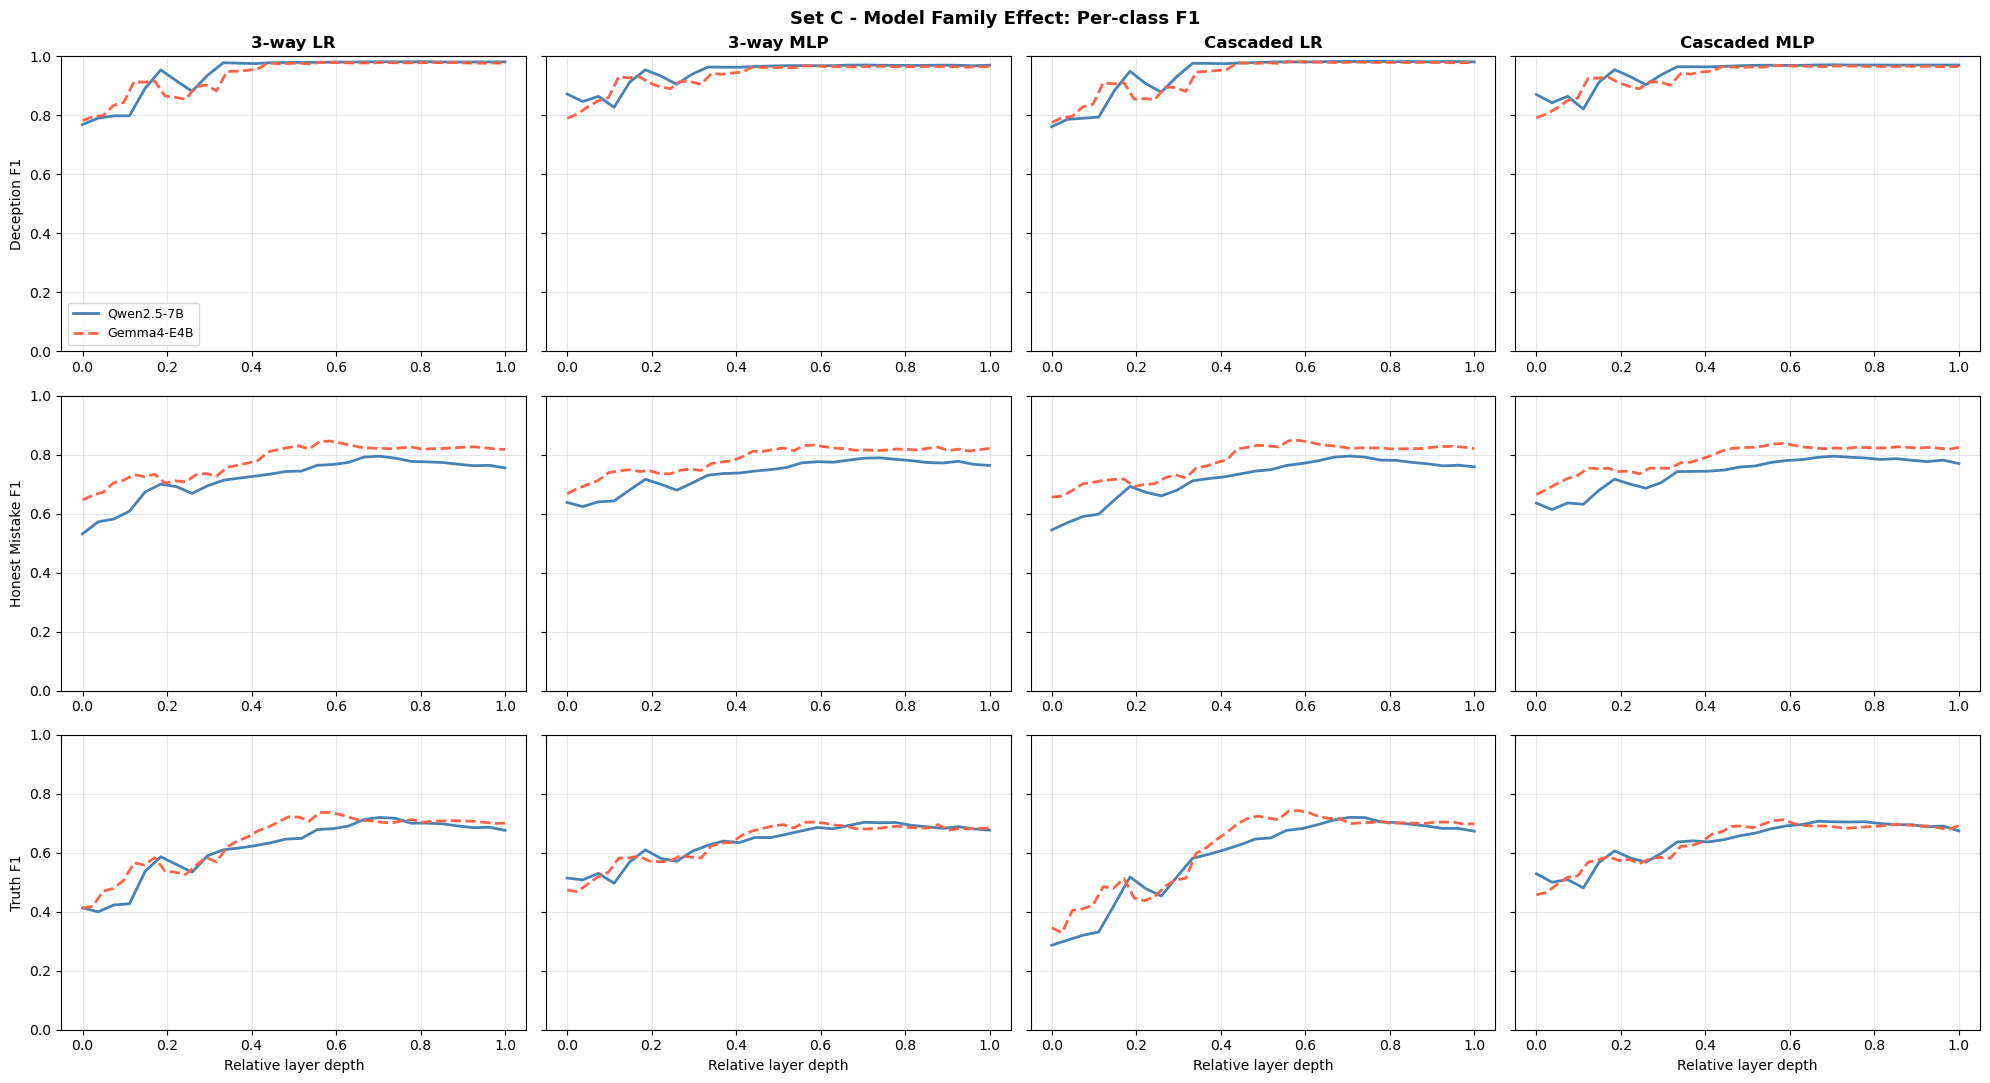

Saved to summary\figures\setC_perclass_f1.png


In [ ]:
# -- Set C: model family (qwen2.5 concise vs gemma4 concise)
# both without thinking mode; x-axis normalized so 28 vs 42 layers align

plot_macro_f1(
    df_concise, "model_family", "qwen2.5", "gemma4",
    "Qwen2.5-7B", "Gemma4-E4B",
    "Set C - Model Family Effect: Macro F1",
    FIG_DIR / "setC_macro_f1.png",
)
plot_perclass_f1(
    df_concise, "model_family", "qwen2.5", "gemma4",
    "Qwen2.5-7B", "Gemma4-E4B",
    "Set C - Model Family Effect: Per-class F1",
    FIG_DIR / "setC_perclass_f1.png",
)

In [ ]:
# -- cascaded MLP stage breakdown helper
# Layout (2x3):
#   Row 0 (Stage 1): f1_truth | f1_non_truth | f1_macro (reference)
#   Row 1 (Stage 2): f1_deception | f1_honest_mistake | stage2_auroc

STAGE_LAYOUT = [
    ("stage1_f1_truth",         "Stage 1 - F1 Truth"),
    ("stage1_f1_non_truth",      "Stage 1 - F1 Non-truth"),
    ("f1_macro",                 "Overall Macro F1 (reference)"),
    ("stage2_f1_deception",      "Stage 2 - F1 Deception"),
    ("stage2_f1_honest_mistake", "Stage 2 - F1 Honest Mistake"),
    ("stage2_auroc",             "Stage 2 - AUROC"),
]
ROW_LABELS = ["Stage 1", "Stage 2"]


def plot_cascaded_stages(df, cond_col, val1, val2, label1, label2, title, save_path):
    """2x3 grid: cascaded MLP stage 1 and stage 2 breakdown."""
    sub = df[(df["classification"] == "cascaded") & (df["classifier"] == "mlp")]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for i, (col_name, subplot_title) in enumerate(STAGE_LAYOUT):
        row, col = divmod(i, 3)
        ax = axes[row, col]
        _draw_lines(ax, sub, cond_col, val1, val2, label1, label2, col_name)
        ax.set_title(subplot_title, fontweight="bold")
        ax.set_xlabel("Relative layer depth")
        if col == 0:
            ax.set_ylabel(ROW_LABELS[row], fontsize=11, fontweight="bold")
        if row == 0 and col == 0:
            ax.legend(fontsize=9)
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {save_path}")

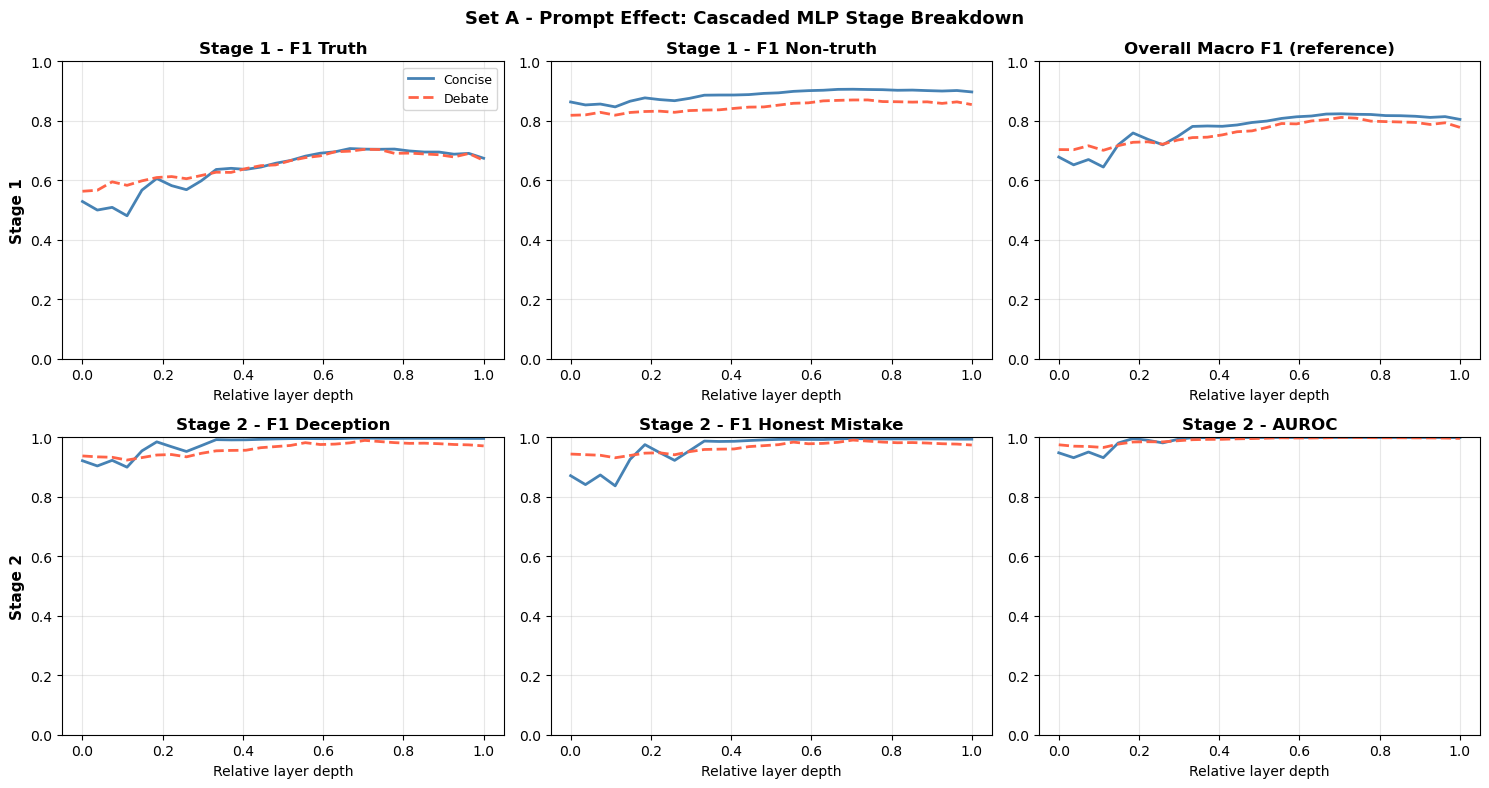

Saved to summary\figures\setA_cascaded_stages.png


In [ ]:
# -- Set A: cascaded MLP stage breakdown (qwen2.5 concise vs debate)
plot_cascaded_stages(
    master[master["model_family"] == "qwen2.5"],
    "prompt", "concise", "debate", "Concise", "Debate",
    "Set A - Prompt Effect: Cascaded MLP Stage Breakdown",
    FIG_DIR / "setA_cascaded_stages.png",
)

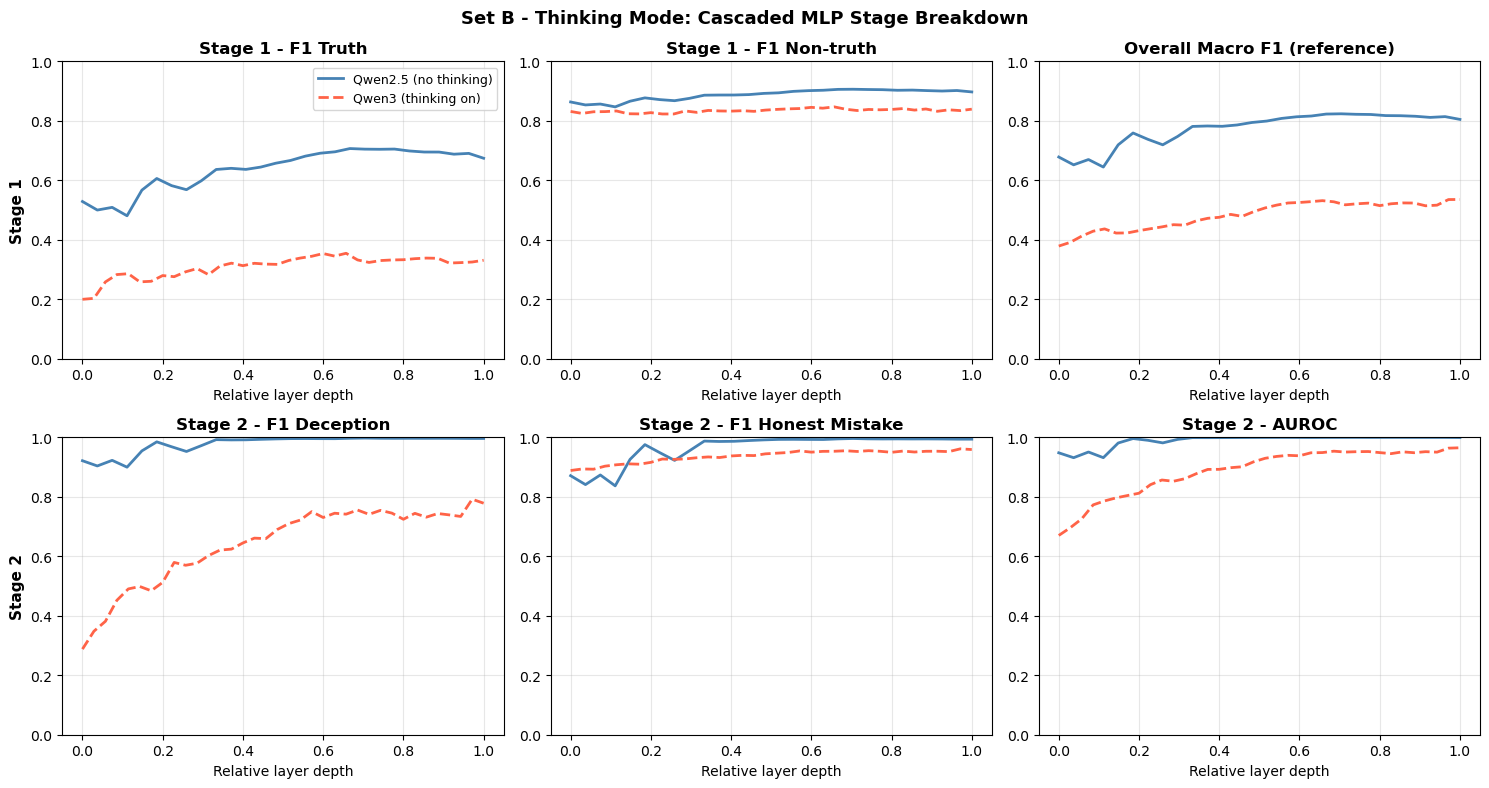

Saved to summary\figures\setB_cascaded_stages.png


In [ ]:
# -- Set B: cascaded MLP stage breakdown (qwen2.5 vs qwen3 concise)
_concise = master[master["prompt"] == "concise"]

plot_cascaded_stages(
    _concise, "model_family", "qwen2.5", "qwen3",
    "Qwen2.5 (no thinking)", "Qwen3 (thinking on)",
    "Set B - Thinking Mode: Cascaded MLP Stage Breakdown",
    FIG_DIR / "setB_cascaded_stages.png",
)

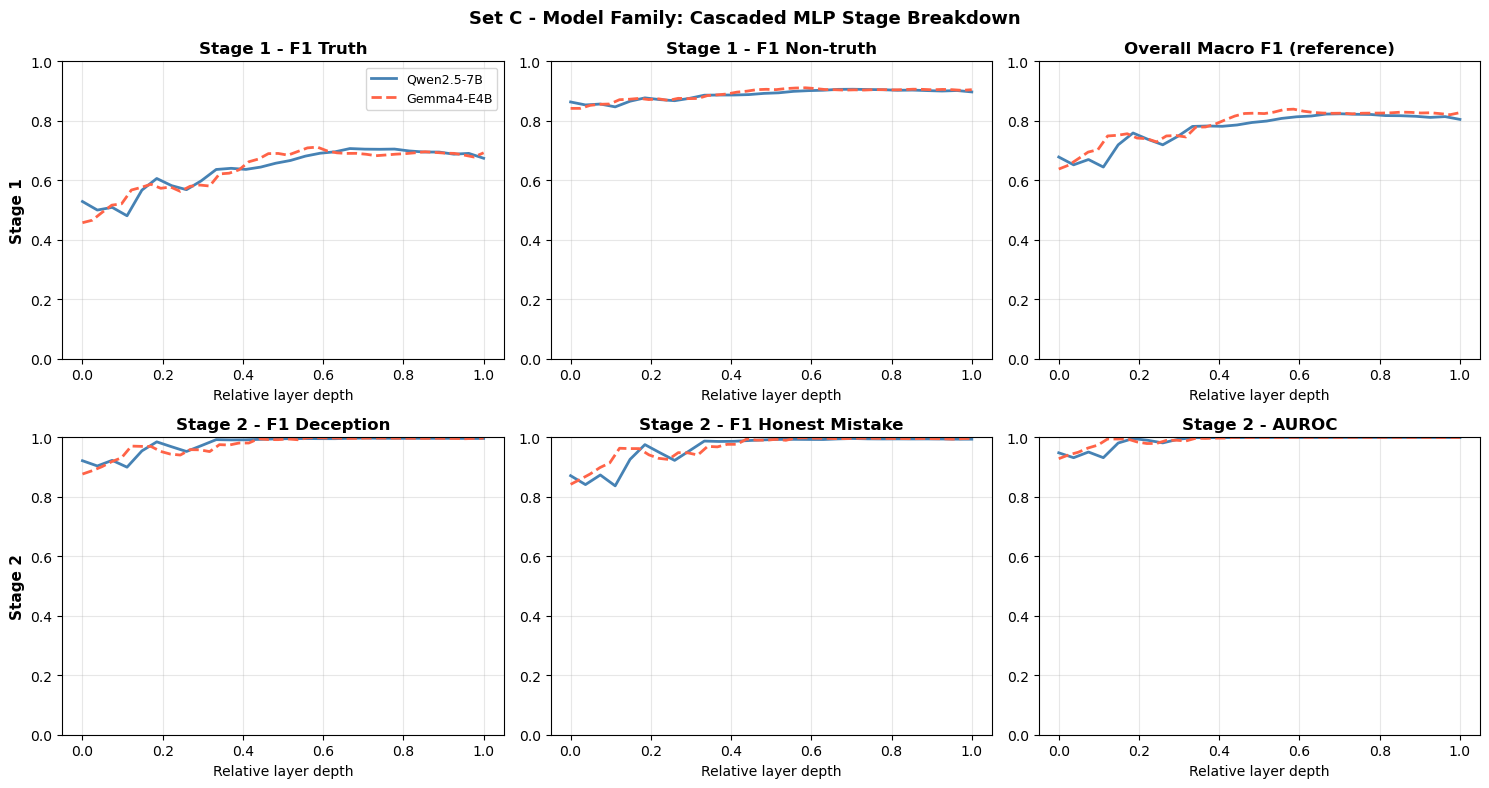

Saved to summary\figures\setC_cascaded_stages.png


In [ ]:
# -- Set C: cascaded MLP stage breakdown (qwen2.5 vs gemma4 concise)
plot_cascaded_stages(
    _concise, "model_family", "qwen2.5", "gemma4",
    "Qwen2.5-7B", "Gemma4-E4B",
    "Set C - Model Family: Cascaded MLP Stage Breakdown",
    FIG_DIR / "setC_cascaded_stages.png",
)

In [ ]:
# -- LR vs MLP comparison tables with Wilcoxon significance
# n = number of layers per model (qwen2.5=28, qwen3=36, gemma4=42)
# Wilcoxon signed-rank test on paired (MLP_f1 - LR_f1) per layer
# Note: adjacent layers are correlated, so p-values are anti-conservative
from scipy import stats

THINKING = {'qwen3': 'on', 'qwen2.5': 'off', 'gemma4': 'off'}
master["thinking"] = master["model_family"].map(THINKING)


def make_comparison_table(metric):
    rows = []
    for (model, cls_type, prompt), grp in master.groupby(
            ['model_family', 'classification', 'prompt'], sort=True):
        lr  = grp[grp["classifier"] == "lr" ][metric].values
        mlp = grp[grp["classifier"] == "mlp"][metric].values
        if len(lr) == 0 or len(mlp) == 0:
            continue
        n = len(lr)
        diff = mlp - lr
        try:
            _, p = stats.wilcoxon(diff)
        except ValueError:
            p = 1.0
        rows.append({
            "model":          model,
            "classification": cls_type,
            "prompt":         prompt,
            "thinking":       THINKING[model],
            "lr_min":         round(lr.min(),  4),
            "lr_mean":        round(lr.mean(), 4),
            "lr_max":         round(lr.max(),  4),
            "mlp_min":        round(mlp.min(),  4),
            "mlp_mean":       round(mlp.mean(), 4),
            "mlp_max":        round(mlp.max(),  4),
            "mlp-lr":         round(diff.mean(), 4),
            "n":              n,
            "p_wilcoxon":     round(p, 4),
        })
    return pd.DataFrame(rows)


METRICS = [
    ("f1_macro",          "macro_f1"),
    ("f1_deception",      "perclass_deception"),
    ("f1_honest_mistake", "perclass_honest_mistake"),
    ("f1_truth",          "perclass_truth"),
]

tables = {}
for metric, name in METRICS:
    t = make_comparison_table(metric)
    tables[name] = t
    out = FIG_DIR.parent / f'lr_vs_mlp_{name}.csv'
    t.to_csv(out, index=False)
    print(f"Saved: {out}")
    display(t)
    print()

Saved: summary\lr_vs_mlp_macro_f1.csv


,model,classification,prompt,thinking,lr_min,lr_mean,lr_max,mlp_min,mlp_mean,mlp_max,mlp-lr,n,p_wilcoxon
0,gemma4,3way,concise,off,0.6136,0.7859,0.8537,0.6435,0.7856,0.8344,-0.0003,42,0.9605
1,gemma4,cascaded,concise,off,0.5923,0.7765,0.8575,0.6378,0.7873,0.8392,0.0108,42,0.4131
2,qwen2.5,3way,concise,off,0.5709,0.7594,0.8319,0.6555,0.7716,0.8205,0.0122,28,0.0946
3,qwen2.5,3way,debate,off,0.6665,0.7534,0.8107,0.6903,0.7555,0.8020,0.0021,28,0.8139
4,qwen2.5,cascaded,concise,off,0.5308,0.7475,0.8324,0.6445,0.7736,0.8236,0.0260,28,0.0009
5,qwen2.5,cascaded,debate,off,0.6686,0.7531,0.8142,0.7008,0.7626,0.8114,0.0095,28,0.0002
6,qwen3,3way,concise,on,0.3310,0.4972,0.5770,0.3954,0.4773,0.5296,-0.0200,36,0.0037
7,qwen3,cascaded,concise,on,0.3117,0.4894,0.5689,0.3788,0.4828,0.5355,-0.0067,36,0.2145



Saved: summary\lr_vs_mlp_perclass_deception.csv


,model,classification,prompt,thinking,lr_min,lr_mean,lr_max,mlp_min,mlp_mean,mlp_max,mlp-lr,n,p_wilcoxon
0,gemma4,3way,concise,off,0.7825,0.9365,0.9794,0.7900,0.9352,0.9679,-0.0013,42,0.6648
1,gemma4,cascaded,concise,off,0.7757,0.9356,0.9819,0.7913,0.9356,0.9683,-0.0000,42,0.7759
2,qwen2.5,3way,concise,off,0.7689,0.9413,0.9820,0.8271,0.9446,0.9707,0.0033,28,0.5824
3,qwen2.5,3way,debate,off,0.8606,0.9214,0.9611,0.8524,0.9000,0.9329,-0.0215,28,0.0000
4,qwen2.5,cascaded,concise,off,0.7615,0.9398,0.9829,0.8213,0.9447,0.9715,0.0049,28,0.5824
5,qwen2.5,cascaded,debate,off,0.8628,0.9244,0.9645,0.8577,0.9048,0.9396,-0.0196,28,0.0000
6,qwen3,3way,concise,on,0.0955,0.3807,0.5339,0.1354,0.2960,0.4057,-0.0846,36,0.0000
7,qwen3,cascaded,concise,on,0.1207,0.4171,0.5501,0.1523,0.3106,0.4325,-0.1065,36,0.0000



Saved: summary\lr_vs_mlp_perclass_honest_mistake.csv


,model,classification,prompt,thinking,lr_min,lr_mean,lr_max,mlp_min,mlp_mean,mlp_max,mlp-lr,n,p_wilcoxon
0,gemma4,3way,concise,off,0.6462,0.7799,0.8457,0.6671,0.7846,0.8323,0.0047,42,0.0868
1,gemma4,cascaded,concise,off,0.6558,0.7792,0.8478,0.6645,0.7891,0.8376,0.0099,42,0.0071
2,qwen2.5,3way,concise,off,0.5311,0.7195,0.7943,0.6236,0.7345,0.7887,0.0150,28,0.0000
3,qwen2.5,3way,debate,off,0.6299,0.7114,0.7731,0.6559,0.7242,0.7778,0.0127,28,0.0000
4,qwen2.5,cascaded,concise,off,0.5444,0.7180,0.7948,0.6132,0.7383,0.7944,0.0203,28,0.0000
5,qwen2.5,cascaded,debate,off,0.6316,0.7121,0.7785,0.6617,0.7342,0.7904,0.0220,28,0.0000
6,qwen3,3way,concise,on,0.7885,0.8284,0.8496,0.7803,0.8191,0.8446,-0.0094,36,0.0000
7,qwen3,cascaded,concise,on,0.7888,0.8303,0.8504,0.7837,0.8283,0.8547,-0.0019,36,0.0577



Saved: summary\lr_vs_mlp_perclass_truth.csv


,model,classification,prompt,thinking,lr_min,lr_mean,lr_max,mlp_min,mlp_mean,mlp_max,mlp-lr,n,p_wilcoxon
0,gemma4,3way,concise,off,0.4122,0.6413,0.7366,0.4677,0.6370,0.7036,-0.0043,42,0.3330
1,gemma4,cascaded,concise,off,0.3290,0.6146,0.7427,0.4575,0.6373,0.7116,0.0227,42,0.3991
2,qwen2.5,3way,concise,off,0.3997,0.6173,0.7196,0.4966,0.6356,0.7032,0.0183,28,0.0191
3,qwen2.5,3way,debate,off,0.4974,0.6273,0.6979,0.5571,0.6424,0.6953,0.0151,28,0.0002
4,qwen2.5,cascaded,concise,off,0.2864,0.5848,0.7198,0.4807,0.6376,0.7067,0.0528,28,0.0001
5,qwen2.5,cascaded,debate,off,0.4974,0.6226,0.6996,0.5637,0.6487,0.7042,0.0261,28,0.0000
6,qwen3,3way,concise,on,0.1090,0.2825,0.3557,0.2681,0.3167,0.3560,0.0341,36,0.0014
7,qwen3,cascaded,concise,on,0.0257,0.2209,0.3225,0.2005,0.3094,0.3561,0.0884,36,0.0000
